<a href="https://colab.research.google.com/github/ho-choi/OpenPCDet/blob/master/Colab_Sample.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Qwen3-VL 기반으로 VML Fine Tuning

---



## GPU 확인하기

In [1]:
!nvidia-smi

Fri Sep 18 00:52:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   50C    P8             13W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA L4


이탤릭체 텍스트## 도구 설치


In [3]:
!pip install -q -U "transformers>=4.57.0" accelerate qwen-vl-utils==0.0.14

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 149.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 78.6 MB/s eta 0:00:00


In [5]:
import transformers
import accelerate

print("transformers:", transformers.__version__)
print("accelerate:", accelerate.__version__)

transformers: 5.17.0
accelerate: 1.15.0


## 모델 불러오기

In [6]:
import torch
from transformers import Qwen3VLForConditionalGeneration, AutoProcessor

model_id = "Qwen/Qwen3-VL-4B-Instruct"


### 1. Model과 Processor — VLM의 두 축

#### 1.1 Model — `Qwen3VLForConditionalGeneration`

- 실제 계산을 수행하는 **신경망 본체(두뇌)**
- 입력: 숫자(텐서) → 출력: 숫자(다음 토큰 확률 분포)
- 클래스 이름 해석
  - `Qwen3VL` : 모델 계열 (Qwen 3세대 Vision-Language)
  - `ForConditionalGeneration` : "조건(이미지+질문)이 주어졌을 때 텍스트를 **생성**하는 용도"의 헤드가 붙어 있다는 뜻
    - 참고: `ForSequenceClassification`, `ForCausalLM` 등은 같은 몸통에 다른 머리(head)를 붙인 것


#### 1.2 Processor — `AutoProcessor`

- Model은 JPG 파일이나 한글 문장을 직접 읽지 못한다.
- Processor는 **사람의 입력을 Model이 먹을 수 있는 숫자로 바꾸는 변환기**.
- `Auto`가 붙은 이유: 모델 이름만 주면 그 모델에 맞는 Processor를 자동으로 골라 로드해 줌.

### Processor = Image Processor + Tokenizer
사실 Processor는 두 개를 합친 것이다.

---



In [9]:
model = Qwen3VLForConditionalGeneration.from_pretrained(
    model_id,
    dtype="auto",
    device_map="auto"
)

processor = AutoProcessor.from_pretrained(model_id)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

In [10]:
print("Model device:", model.device)

print(
    "GPU memory allocated:",
    round(torch.cuda.memory_allocated() / 1024**3, 2),
    "GB"
)

Model device: cuda:0
GPU memory allocated: 8.27 GB



## 이미지 불러와서 확인



In [12]:
from google.colab import files

uploaded = files.upload()

Saving ChatGPT Image 2026년 8월 27일 오후 05_22_43.png to ChatGPT Image 2026년 8월 27일 오후 05_22_43.png


In [14]:
image_name = next(iter(uploaded))

print("업로드된 파일:", image_name)

업로드된 파일: ChatGPT Image 2026년 8월 27일 오후 05_22_43.png


이미지 크기: (1672, 941)
이미지 모드: RGB


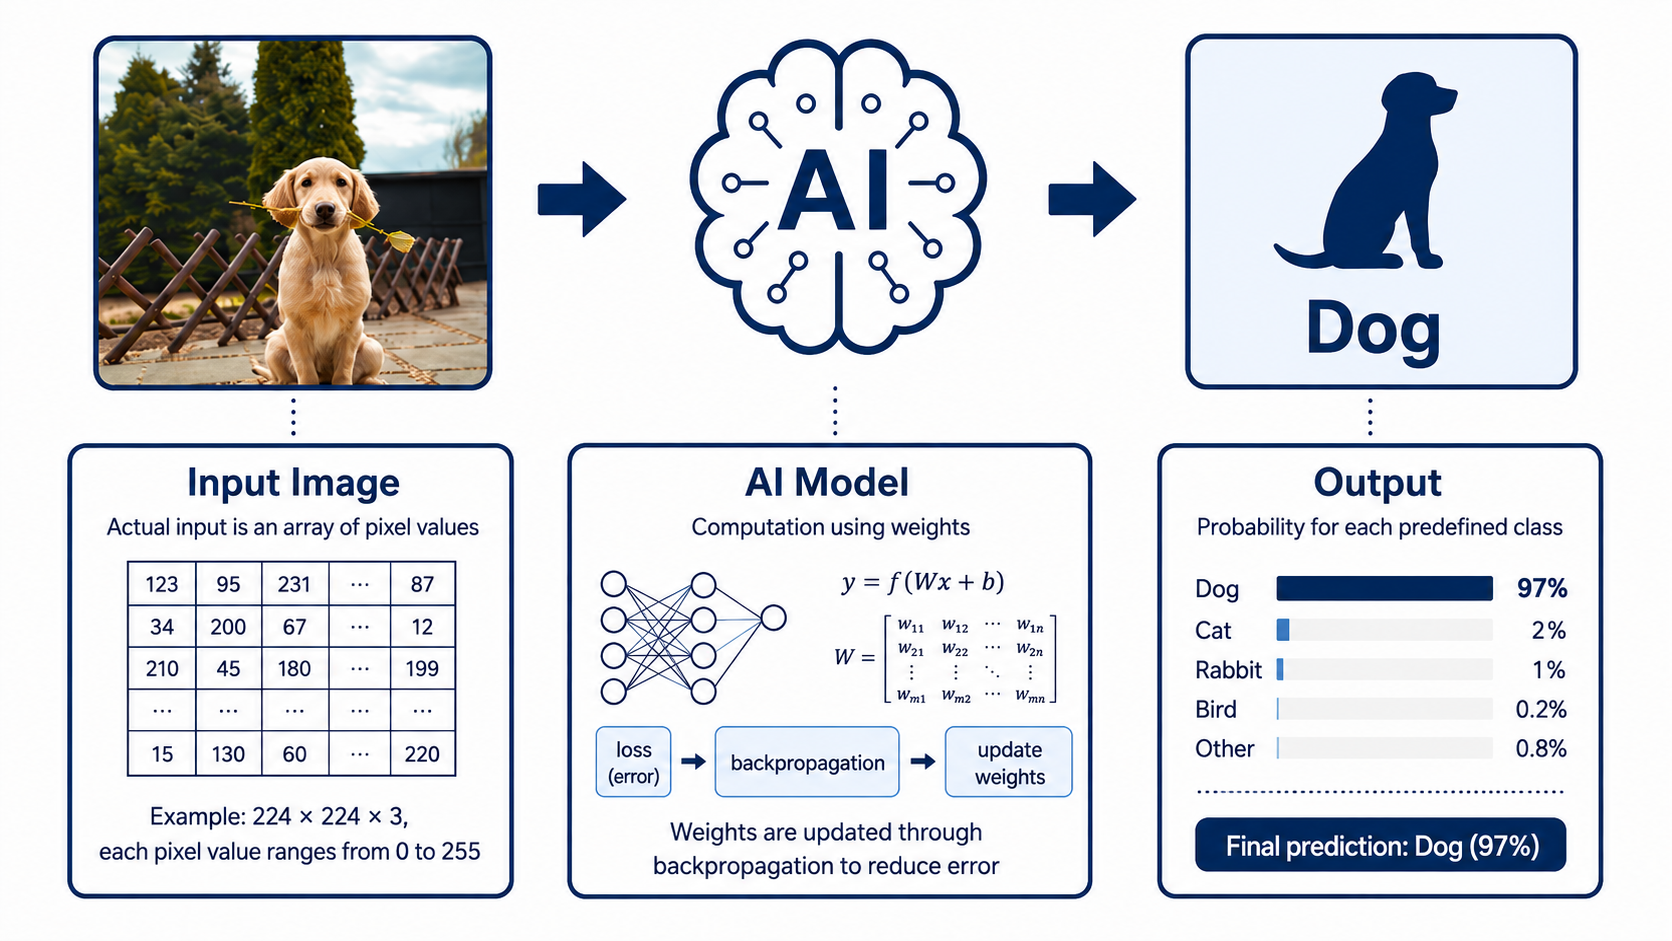

In [15]:
from PIL import Image

image_path = f"/content/{image_name}"

image = Image.open(image_path).convert("RGB")

print("이미지 크기:", image.size)
print("이미지 모드:", image.mode)

display(image)

## Qwen3에 입력할 수 있는 Input 값 변환

### Qwen 입력값:

🖼️ [사진] +
💬 "Describe this image in one sentence."

를 하나의 메시지로 정의

In [21]:
from pathlib import Path

image_uri = Path(image_path).resolve().as_uri()

print(image_uri)

file:///content/ChatGPT%20Image%202026%EB%85%84%208%EC%9B%94%2027%EC%9D%BC%20%EC%98%A4%ED%9B%84%2005_22_43.png


In [22]:
messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": image_path
            },
            {
                "type": "text",
                "text": "Describe this image in one sentence."
            }
        ]
    }
]

## Processor가 입력값 변환

In [23]:
from qwen_vl_utils import process_vision_info

text = processor.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

images, videos = process_vision_info(
    messages,
    image_patch_size=16
)

In [24]:
inputs = processor(
    text=text,
    images=images,
    videos=videos,
    do_resize=False,
    return_tensors="pt"
)

inputs = inputs.to(model.device)

In [25]:
print(inputs.keys())

KeysView({'input_ids': tensor([[151644,    872,    198,  ..., 151644,  77091,    198]],
       device='cuda:0'), 'attention_mask': tensor([[1, 1, 1,  ..., 1, 1, 1]], device='cuda:0'), 'mm_token_type_ids': tensor([[0, 0, 0,  ..., 0, 0, 0]], device='cuda:0'), 'pixel_values': tensor([[0.9608, 0.9686, 0.9765,  ..., 0.9843, 0.9843, 0.9765],
        [0.9843, 0.9843, 0.9843,  ..., 0.9843, 0.9843, 0.9843],
        [0.9765, 0.9843, 0.9843,  ..., 0.9765, 0.9843, 0.9843],
        ...,
        [0.9843, 0.9843, 0.9922,  ..., 0.9922, 0.9843, 0.9922],
        [0.9843, 0.9843, 0.9843,  ..., 0.9686, 0.9686, 0.9686],
        [0.9843, 0.9843, 0.9843,  ..., 0.9765, 0.9843, 0.9686]],
       device='cuda:0'), 'image_grid_thw': tensor([[  1,  58, 104]], device='cuda:0')})


In [26]:
for key, value in inputs.items():
    if hasattr(value, "shape"):
        print(key, ":", value.shape)

input_ids : torch.Size([1, 1525])
attention_mask : torch.Size([1, 1525])
mm_token_type_ids : torch.Size([1, 1525])
pixel_values : torch.Size([6032, 1536])
image_grid_thw : torch.Size([1, 3])


## 모델에 질문하기

In [27]:
with torch.no_grad():
    generated_ids = model.generate(
        **inputs,
        max_new_tokens=128
    )

In [28]:
print(generated_ids.shape)

torch.Size([1, 1569])


## 2. 생성 결과에서 입력 부분 잘라내기

## 핵심
`model.generate()`의 출력은 **[입력 토큰] + [새로 생성한 토큰]** 이 한 줄로 붙어 있다.
답변만 보려면 입력 길이만큼 앞을 잘라야 한다.

```python
generated_ids_trimmed = generated_ids[:, inputs["input_ids"].shape[1]:]
```

- `inputs["input_ids"].shape` = `[1, 1525]` → `[배치 크기, 입력 토큰 수]`
- `shape[1]` = 1525 = 잘라낼 길이
- `[:, 1525:]` → 모든 배치에서 1525번째부터 끝까지만 남김

```
generated_ids
[ 입력 토큰 1525개 ][ 새로 생성한 답변 토큰 ]
└──── 제거 ────────┘└──── 우리가 원하는 부분 ────┘
```

## 왜 입력이 붙어 나오는가
디코더 모델은 "지금까지의 시퀀스 → 다음 토큰"을 반복한다. 입력 시퀀스 뒤에 계속 이어 붙이는 구조라 결과에 입력이 그대로 포함된다.

## 안 자르면 생기는 일
- decode 결과에 질문(프롬프트)이 통째로 다시 출력됨
- 이미지 자리표시 토큰 1000개 이상이 특수 문자로 섞여 나옴

## 기억할 것
- 자르는 기준은 **항상 `inputs["input_ids"].shape[1]`** (하드코딩 금지 — 이미지 크기·질문 길이에 따라 매번 달라짐)
- 자른 뒤 `processor.batch_decode(..., skip_special_tokens=True)`로 텍스트 복원

In [29]:
generated_ids_trimmed = generated_ids[:, inputs["input_ids"].shape[1]:]

print(generated_ids_trimmed.shape)

torch.Size([1, 44])


## 결과 숫자를 문장으로 바꾸기

In [30]:
output_text = processor.batch_decode(
    generated_ids_trimmed,
    skip_special_tokens=True,
    clean_up_tokenization_spaces=False
)

print(output_text[0])

This infographic illustrates how an AI model processes an input image of a dog, computes probabilities for various classes using weights and backpropagation, and outputs a final prediction of "Dog" with 97% confidence.


##
##  VLM Inference 전체 파이프라인 정리

```
이미지 + 질문
     ↓
Processor              ← encode: 이미지→pixel_values, 텍스트→input_ids
     ↓
Token / Pixel Values
     ↓
Qwen3-VL               ← Vision Encoder + Projector + LLM
     ↓
generate()             ← 다음 토큰을 한 개씩 반복 예측 (자기회귀)
     ↓
숫자 Token ID          ← [입력 토큰][답변 토큰] 형태 → 입력 길이만큼 잘라냄
     ↓
decode()               ← Processor(Tokenizer)로 번호 → 문자
     ↓
자연어 답변
```

## 단계별 한 줄 요약
| 단계 | 하는 일 | 담당 객체 |
|---|---|---|
| 1. 입력 준비 | 이미지 + 질문을 채팅 템플릿에 맞춰 구성 | 사람 / `apply_chat_template` |
| 2. 전처리 | 숫자 텐서로 변환 | Processor |
| 3. 생성 | 토큰 ID 시퀀스 출력 | Model.`generate()` |
| 4. 잘라내기 | 입력 부분 제거 | 슬라이싱 |
| 5. 후처리 | 토큰 ID → 텍스트 | Processor.`batch_decode()` |

## 이것이 "기본 구조"인 이유
- 모델이 LLaVA, PaliGemma, Gemma-3 등으로 바뀌어도 이 뼈대는 동일하다.
- 달라지는 건 클래스 이름, 채팅 템플릿 형식, 이미지 토큰 개수 정도.

## 학습(Fine-tuning)과의 연결
추론 파이프라인을 이해하면 학습은 한 가지만 추가된다.
```
... → Model → 출력 토큰 확률
                 ↓
        정답 토큰과 비교 (loss)
                 ↓
           역전파로 가중치 업데이트
```
즉 `generate()` 대신 `forward()`로 loss를 계산하는 것이 학습이다. 다음 단계에서 다룰 내용.

# Fine Tuning

## LoRA (Low-Rank Adaptation)

### 정의
기존 모델 가중치는 **고정(freeze)** 하고, 옆에 작은 **어댑터(Adapter)** 를 붙여 그것만 학습하는 파인튜닝 기법.

```
기존 Qwen3-VL [████████████████████████████████]  ← 고정 (학습 안 함)
                +
LoRA Adapter   [██]                                ← 이것만 학습
```

## LoRA 도구 설치

In [31]:
!pip install -q -U peft datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.9/832.9 kB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 50.8 MB/s eta 0:00:00


In [32]:
import peft
import datasets

print("PEFT:", peft.__version__)
print("Datasets:", datasets.__version__)

PEFT: 0.21.0
Datasets: 5.0.1
